In [180]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading dataset

In [181]:
df = pd.read_csv('Seed_Data.csv')

In [182]:
df.head()

,A,P,C,LK,WK,A_Coef,LKG,target
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,0
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,0
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,0
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,0


In [183]:
df.shape

(210, 8)

Check for missing values and duplicates in the dataset

In [184]:
# check for missing values
df.isnull().sum()

,0
A,0
P,0
C,0
LK,0
WK,0
A_Coef,0
LKG,0
target,0





No missing values in the given dataset

Check for duplicates

In [185]:
df.duplicated().sum()

np.int64(0)

No duplicate values in the given dataset

In [186]:
X = df.drop('target',axis=1)
y = df['target']

In [187]:
np.unique(y)

array([0, 1, 2])

# KMeans++ from Scratch

In [189]:
def KMeansPP_scratch(input=None, clusters=3, tolerance=1e-3, max_iterations=100):
    np.random.seed(42)

    num_samples = input.shape[0]
    sample_clusters = np.zeros(num_samples)
    centroids = []

    # Choose first centroid randomly
    first = np.random.randint(num_samples)
    centroids.append(input[first])

    # Choose remaining centroids using weighted probability
    for _ in range(1, clusters):
        distances = np.array([min(np.linalg.norm(x - c)**2 for c in centroids) for x in input])
        probabilities = distances / np.sum(distances)
        next = np.random.choice(range(num_samples), p=probabilities)
        centroids.append(input[next])
    centroids = np.array(centroids)

    # Standard K-Means
    iteration = 0
    prev_centroids = np.zeros_like(centroids)

    while (iteration < max_iterations) and (np.linalg.norm(centroids - prev_centroids) > tolerance):
        prev_centroids = centroids.copy()

        # Assign samples to nearest centroid
        for i in range(num_samples):
            distances = [np.linalg.norm(input[i] - centroids[j]) for j in range(clusters)]
            sample_clusters[i] = np.argmin(distances)

        # Update centroids as mean of assigned samples
        for i in range(clusters):
            points = input[sample_clusters == i]
            if len(points) > 0:
                centroids[i] = np.mean(points, axis=0)

        iteration += 1

    return centroids, sample_clusters

In [191]:
centroids, sample_clusters = KMeansPP_scratch(X.values, clusters=3)

# Cluster evaluation

In [192]:
from sklearn.metrics import silhouette_score, rand_score, adjusted_rand_score
print("Silhouette Score: ", silhouette_score(X, sample_clusters))
print("Rand Score: ", rand_score(y, sample_clusters))
print("Adjusted Rand Score: ", adjusted_rand_score(y, sample_clusters))

Silhouette Score:  0.4719337319126887
Rand Score:  0.8743677375256322
Adjusted Rand Score:  0.7166198557361053


# Ground Truth Comparison and Label Assignment

In [193]:
comparison_table = pd.crosstab(y, sample_clusters, rownames=['True Label'], colnames=['Cluster'])
print("Cluster vs True Label (Scratch):")
print(comparison_table)

Cluster vs True Label (Scratch):
Cluster     0.0  1.0  2.0
True Label               
0             1    9   60
1            60    0   10
2             0   68    2


In [195]:
# Assigning labels to clusters
cluster_labels = {}
for c in comparison_table.columns:
    majority_label = comparison_table[c].idxmax()
    cluster_labels[c] = majority_label

y_pred = np.array([cluster_labels[int(c)] for c in sample_clusters])

In [196]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

acc = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred, average='macro')
rec = recall_score(y, y_pred, average='macro')

print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")


Accuracy: 0.895
Precision: 0.900
Recall: 0.895


# Clustering using Sklearn K-Means ++

In [197]:
from sklearn.cluster import KMeans

kmeans_sklearn = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans_sklearn.fit(X)

centroids_sklearn = kmeans_sklearn.cluster_centers_
sample_clusters_sklearn = kmeans_sklearn.labels_


In [198]:
silhouette_sklearn = silhouette_score(X, sample_clusters_sklearn)
rand_sklearn = rand_score(y, sample_clusters_sklearn)
adj_rand_sklearn = adjusted_rand_score(y, sample_clusters_sklearn)

print("Sklearn KMeans Results")
print("Silhouette Score:", silhouette_sklearn)
print("Rand Score:", rand_sklearn)
print("Adjusted Rand Score:", adj_rand_sklearn)

Sklearn KMeans Results
Silhouette Score: 0.4719337319126887
Rand Score: 0.8743677375256322
Adjusted Rand Score: 0.7166198557361053


In [199]:
#Compare with from-scratch implementation
print("Comparison with From-Scratch Implementation")
print("Silhouette Score(Scratch):", silhouette_score(X, sample_clusters))
print("Silhouette Score(Sklearn):", silhouette_sklearn)
print("Rand Score(Scratch):", rand_score(y, sample_clusters))
print("Rand Score(Sklearn):", rand_sklearn)
print("Adjusted Rand Score(Scratch):", adjusted_rand_score(y, sample_clusters))
print("Adjusted Rand Score(Sklearn):", adj_rand_sklearn)

Comparison with From-Scratch Implementation
Silhouette Score(Scratch): 0.4719337319126887
Silhouette Score(Sklearn): 0.4719337319126887
Rand Score(Scratch): 0.8743677375256322
Rand Score(Sklearn): 0.8743677375256322
Adjusted Rand Score(Scratch): 0.7166198557361053
Adjusted Rand Score(Sklearn): 0.7166198557361053


# Label Assignment and Evaluation for sklearn clustering

In [200]:
comparison_table_sklearn = pd.crosstab(y, sample_clusters_sklearn, rownames=['True Label'], colnames=['Cluster'])
print("Cluster vs True Label (Sklearn):")
print(comparison_table_sklearn)

Cluster vs True Label (Sklearn):
Cluster      0   1   2
True Label            
0            1   9  60
1           60   0  10
2            0  68   2


In [201]:
# Assign labels to each cluster
cluster_labels_sklearn = {}
for c in comparison_table_sklearn.columns:
    majority_label = comparison_table_sklearn[c].idxmax()
    cluster_labels_sklearn[c] = majority_label

y_pred_sklearn = np.array([cluster_labels[int(c)] for c in sample_clusters_sklearn])

In [202]:
acc_sklearn = accuracy_score(y, y_pred_sklearn)
prec_sklearn = precision_score(y, y_pred_sklearn, average='macro')
rec_sklearn = recall_score(y, y_pred_sklearn, average='macro')

print(f"Accuracy (Sklearn): {acc_sklearn:.3f}")
print(f"Precision (Sklearn): {prec_sklearn:.3f}")
print(f"Recall (Sklearn): {rec_sklearn:.3f}")

Accuracy (Sklearn): 0.895
Precision (Sklearn): 0.900
Recall (Sklearn): 0.895


Comparison of the sklearn implementation with the from scratch implementation

In [203]:
print(f"Accuracy (Scratch): {acc:.3f}")
print(f"Precision (Scratch): {prec:.3f}")
print(f"Recall (Scratch): {rec:.3f}")
print(f"Accuracy (Sklearn): {acc_sklearn:.3f}")
print(f"Precision (Sklearn): {prec_sklearn:.3f}")
print(f"Recall (Sklearn): {rec_sklearn:.3f}")

Accuracy (Scratch): 0.895
Precision (Scratch): 0.900
Recall (Scratch): 0.895
Accuracy (Sklearn): 0.895
Precision (Sklearn): 0.900
Recall (Sklearn): 0.895


# Visualize the clusters for both scratch and sklearn implementation

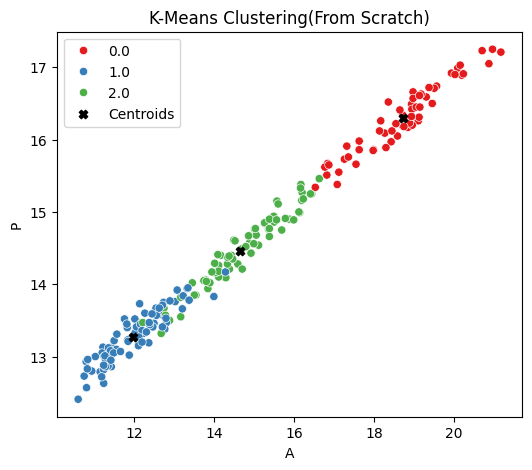

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=X.iloc[:,0], y=X.iloc[:,1], hue=sample_clusters, palette='Set1')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', label='Centroids')
plt.title("K-Means Clustering (From Scratch)")
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.legend()
plt.show()

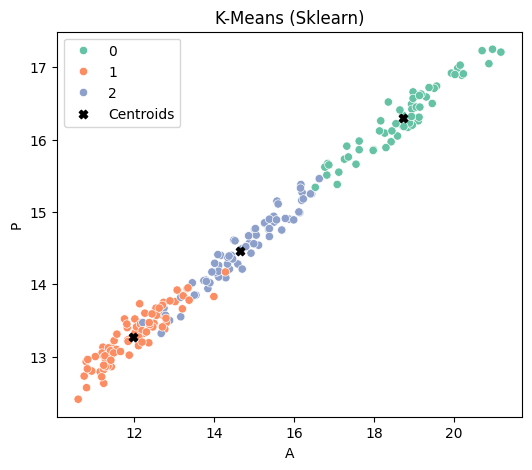

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=X.iloc[:,0], y=X.iloc[:,1], hue=sample_clusters_sklearn, palette='Set2')
plt.scatter(centroids_sklearn[:,0], centroids_sklearn[:,1], c='black', marker='X', label='Centroids')
plt.title("K-Means Clustering (Sklearn)")
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.legend()
plt.show()